# 📊  – Analyse des données MovieLens (PostgreSQL)

## Bloc 1 – Statistiques globales

### 🧠 Contexte

Avant d'extraire des insights avancés, il est essentiel de comprendre les **grands chiffres** de notre dataset MovieLens :

- Combien d’utilisateurs, de films, de notes et de tags contient-il ?
- Quelle est la **moyenne globale des notes** et leur **dispersion** ?

Ces indicateurs permettent d’avoir une **vue d’ensemble** sur la densité, la qualité et la complexité des données à explorer.


In [2]:
# 📦 Importations des bibliothèques essentielles
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# 🎨 Configuration du style graphique
sns.set(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (10, 5)

# 🔌 Connexion à PostgreSQL (à adapter si nécessaire)
user = "postgres"
password = "dadoo"
host = "localhost"
port = "5432"
database = "movielens"

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

# ✅ Confirmation de démarrage
print("🔗 Environnement prêt : bibliothèques chargées, connexion à PostgreSQL établie.")


🔗 Environnement prêt : bibliothèques chargées, connexion à PostgreSQL établie.


### 📄 Requête SQL

La requête ci-dessous utilise des **Common Table Expressions (CTE)** pour calculer proprement et efficacement :

- Le nombre de films (`movies`)
- Le nombre total de notes (`ratings`)
- Le nombre d’utilisateurs uniques
- Le nombre de tags (`tags`)
- La moyenne et l’écart-type des notes

Chaque agrégation est encapsulée dans une CTE, puis combinée via des `CROSS JOIN` pour produire un seul tableau de statistiques.


In [5]:
# ✅  Statistiques globales sur les données MovieLens

query = """
WITH movie_count AS (
    SELECT COUNT(*) AS total_movies FROM movies
),
rating_stats AS (
    SELECT 
        COUNT(*) AS total_ratings,
        COUNT(DISTINCT "userId") AS total_users,
        ROUND(AVG(rating)::numeric, 2) AS moyenne_notes,
        ROUND(STDDEV(rating)::numeric, 2) AS ecart_type_notes
    FROM ratings
),
tag_count AS (
    SELECT COUNT(*) AS total_tags FROM tags
)
SELECT 
    m.total_movies,
    r.total_ratings,
    r.total_users,
    t.total_tags,
    r.moyenne_notes,
    r.ecart_type_notes
FROM movie_count m
CROSS JOIN rating_stats r
CROSS JOIN tag_count t;
"""

# 🧪 Exécution de la requête et affichage dans un DataFrame
df_stats = pd.read_sql_query(query, engine)
df_stats


,total_movies,total_ratings,total_users,total_tags,moyenne_notes,ecart_type_notes
0,9742,100836,610,3423,3.5,1.04


### 📈 Interprétation des résultats

| Indicateur | Interprétation métier |
|------------|------------------------|
| **Total de films** | Diversité du catalogue disponible |
| **Total de notes** | Densité des interactions utilisateurs |
| **Total d'utilisateurs** | Taille de la base d’usagers actifs |
| **Total de tags** | Richesse des métadonnées qualitatives |
| **Moyenne des notes** | Tendances globales de satisfaction |
| **Écart-type des notes** | Degré d’hétérogénéité des opinions |

👉 Ces premiers résultats posent les bases pour **segmenter les comportements**, **détecter les films extrêmes**, ou **construire un moteur de recommandation** plus tard.


## 🎯 Répartition des notes données par les utilisateurs

Pour mieux comprendre les comportements de notation, nous analysons ici la **distribution des scores** attribués aux films.  
Cela permet d'identifier d'éventuels biais (par exemple, une surutilisation des notes extrêmes comme 0.5 ou 5.0), ou au contraire, une dispersion équilibrée.

> Cette étape est importante pour évaluer la qualité moyenne des notations et ajuster de futures analyses (comme un score pondéré).


In [6]:
# ✅ Requête SQL pour analyser la distribution des notes
query = """
SELECT 
    rating,
    COUNT(*) AS nb_votes,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pourcentage
FROM ratings
GROUP BY rating
ORDER BY rating;
"""

df_repartition_notes = pd.read_sql_query(query, engine)
df_repartition_notes


,rating,nb_votes,pourcentage
0,0.5,1370,1.36
1,1.0,2811,2.79
2,1.5,1791,1.78
3,2.0,7551,7.49
4,2.5,5550,5.50
5,3.0,20047,19.88
6,3.5,13136,13.03
7,4.0,26818,26.60
8,4.5,8551,8.48
9,5.0,13211,13.10


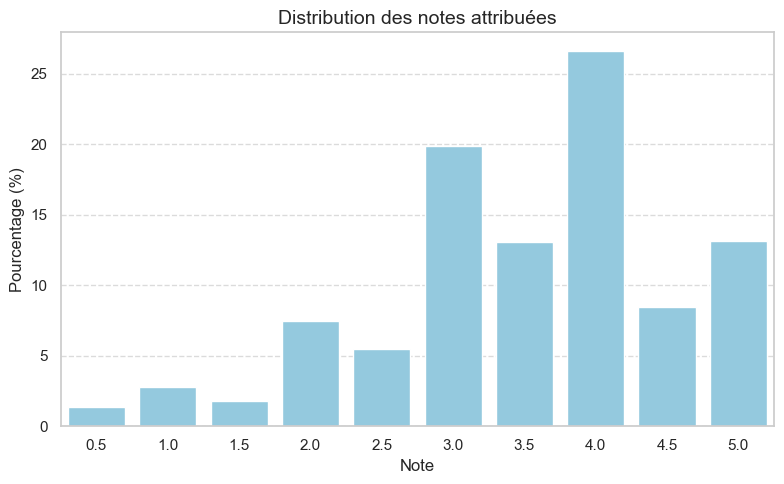

In [7]:


# ✅ Tracé de la répartition des notes
plt.figure(figsize=(8, 5))
sns.barplot(data=df_repartition_notes, x='rating', y='pourcentage', color='skyblue')

plt.title("Distribution des notes attribuées", fontsize=14)
plt.xlabel("Note")
plt.ylabel("Pourcentage (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 🔍 Interprétation

On observe ici la **fréquence de chaque note** attribuée dans le dataset.  
Quelques points à surveiller :

- Les notes **pleines** (3.0, 4.0, 5.0) sont souvent surreprésentées par rapport aux notes intermédiaires.
- Il est important de repérer s’il existe un **effet de biais de notation** (note par défaut, abus de notes extrêmes, etc.)
- Ces observations orienteront la construction future d’un **score pondéré** plus fiable.

> L’analyse montre que les utilisateurs ont tendance à éviter les notes faibles (<2.0), ce qui pourrait biaiser la moyenne simple.


## 🔍 Analyse des cas extrêmes

Nous allons maintenant identifier trois catégories particulières de films :

- 🎖️ Les **mieux notés** : films avec les moyennes les plus élevées
- 🧨 Les **plus mal notés** : films les plus boudés par les utilisateurs
- ⚖️ Les **plus controversés** : films qui divisent, avec un écart-type élevé

ℹ️ **Seuls les films avec au moins 50 notes** sont conservés pour assurer la fiabilité statistique.


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_12176\3060834895.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="avg_rating", y="title", data=top_rated, ax=axs[0], palette="Greens_d")
C:\Users\Hammiche\AppData\Local\Temp\ipykernel_12176\3060834895.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="avg_rating", y="title", data=worst_rated, ax=axs[1], palette="Reds_d")
C:\Users\Hammiche\AppData\Local\Temp\ipykernel_12176\3060834895.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="std_rating", y="title", data=most_controversi

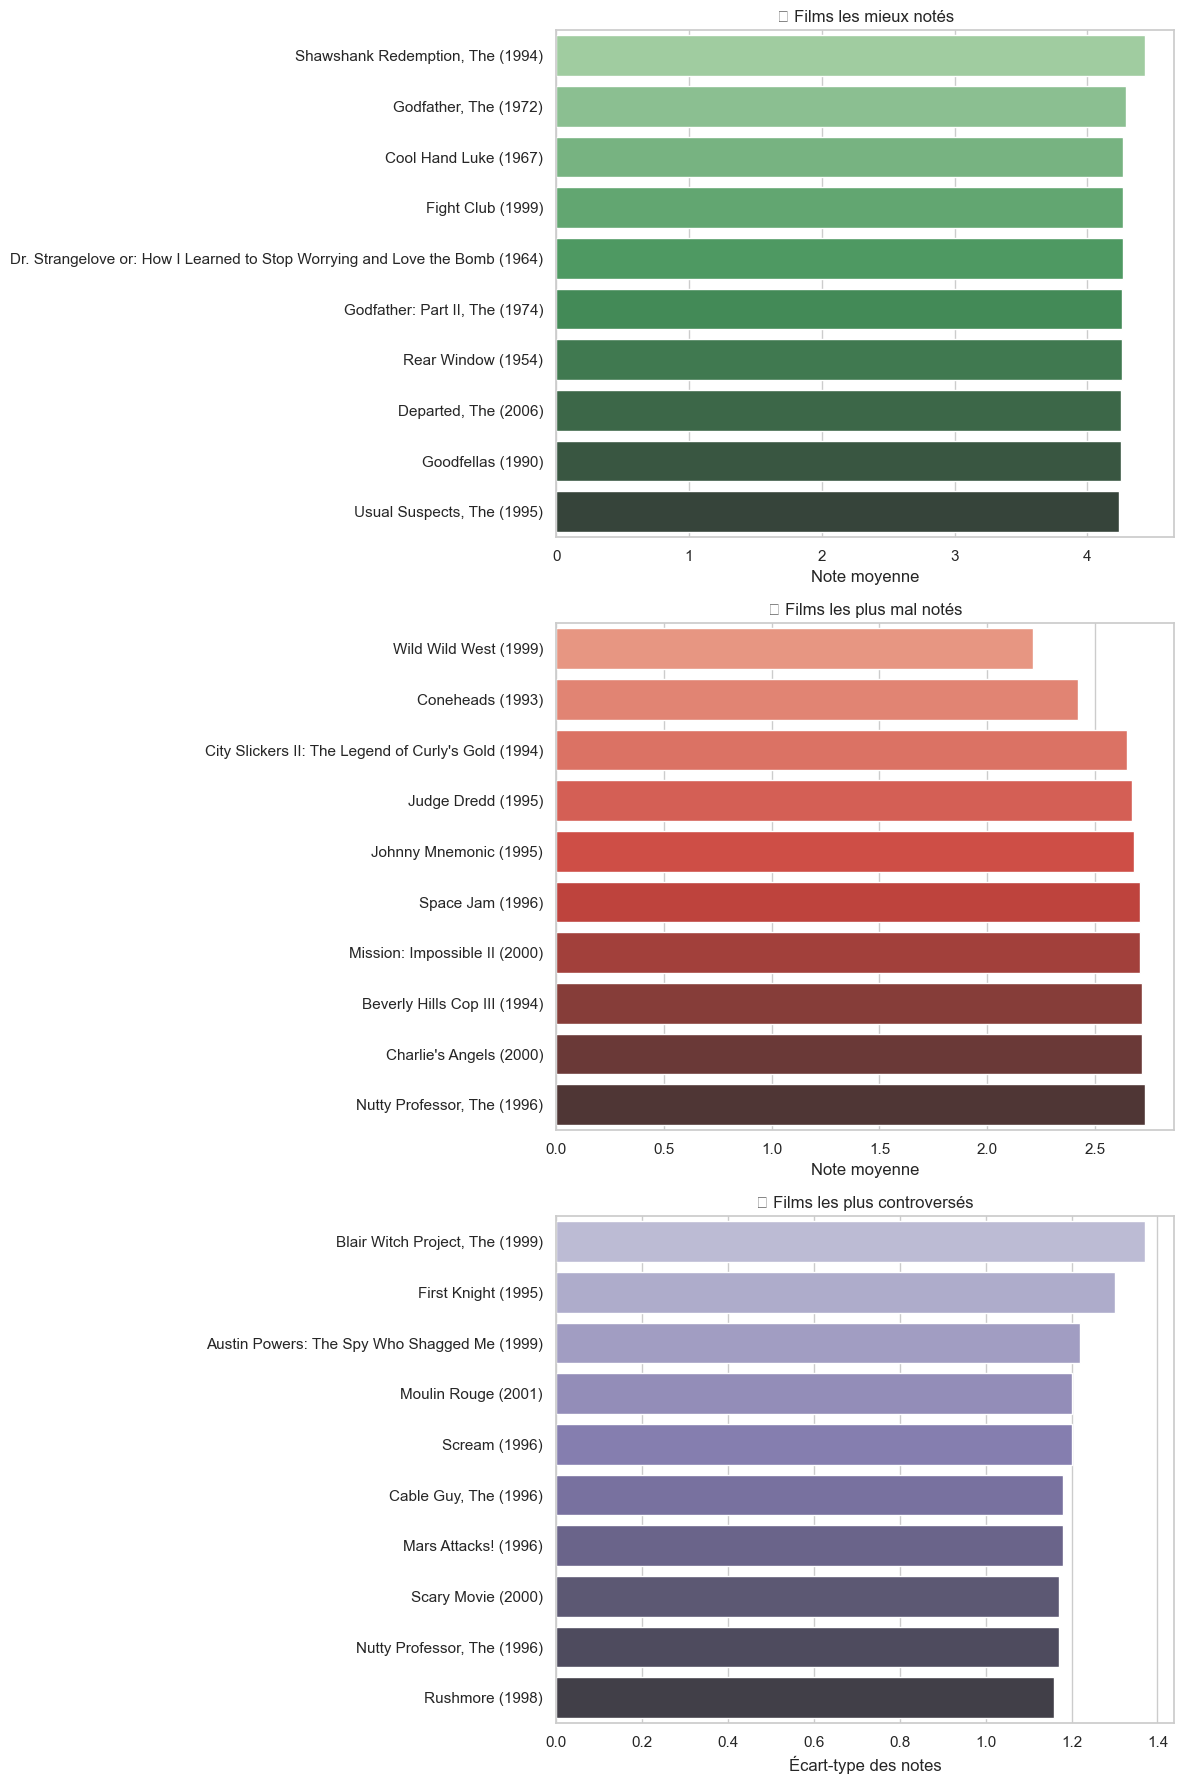

In [8]:

# Requête SQL : récupérer les statistiques des films avec au moins 50 notes
query_extremes = """
WITH stats AS (
    SELECT
        m."title",
        COUNT(r."rating") AS nb_ratings,
        ROUND(AVG(r."rating")::numeric, 2) AS avg_rating,
        ROUND(STDDEV(r."rating")::numeric, 2) AS std_rating
    FROM ratings r
    JOIN movies m ON m."movieId" = r."movieId"
    GROUP BY m."title"
    HAVING COUNT(r."rating") >= 50
)
SELECT * FROM stats;
"""

# Charger les données dans un DataFrame
df_extremes = pd.read_sql_query(query_extremes, engine)

# Extraire les cas extrêmes
top_rated = df_extremes.sort_values(by="avg_rating", ascending=False).head(10)
worst_rated = df_extremes.sort_values(by="avg_rating").head(10)
most_controversial = df_extremes.sort_values(by="std_rating", ascending=False).head(10)

# Visualisation
fig, axs = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(x="avg_rating", y="title", data=top_rated, ax=axs[0], palette="Greens_d")
axs[0].set_title("🎬 Films les mieux notés")
axs[0].set_xlabel("Note moyenne")
axs[0].set_ylabel("")

sns.barplot(x="avg_rating", y="title", data=worst_rated, ax=axs[1], palette="Reds_d")
axs[1].set_title("🎬 Films les plus mal notés")
axs[1].set_xlabel("Note moyenne")
axs[1].set_ylabel("")

sns.barplot(x="std_rating", y="title", data=most_controversial, ax=axs[2], palette="Purples_d")
axs[2].set_title("🎬 Films les plus controversés")
axs[2].set_xlabel("Écart-type des notes")
axs[2].set_ylabel("")

plt.tight_layout()
plt.show()

### 🎯 Interprétation

- Les films les **mieux notés** sont généralement des classiques très appréciés ou des chefs-d'œuvre reconnus.
- Les films les **plus mal notés** sont souvent des productions faibles ou des échecs critiques.
- Les films **controversés** génèrent des réactions polarisées : certains adorent, d'autres détestent.

👉 Cette analyse est utile pour détecter des films "coup de cœur universels" ou au contraire, des titres clivants, ce qui est précieux pour une stratégie de recommandation ou d’achat de droits.


### 3. 🎬 Popularité VS Qualité

Dans cette section, nous explorons le lien entre **popularité** (nombre de notes) et **qualité perçue** (note moyenne). 

Un film avec une très bonne note mais peu de votes peut être **peu fiable**. À l'inverse, un film très noté mais avec une moyenne correcte peut tout de même être **recommandable**, car largement validé.

Pour objectiver cela, nous utilisons une méthode inspirée du **score pondéré IMDb**, qui combine :
- la **note moyenne du film** (`R`)
- le **nombre de votes** pour ce film (`v`)
- la **note moyenne globale** sur l'ensemble des films (`C`)
- un **seuil de votes minimum** (`m`) pour garantir la représentativité

📐 **Formule du score pondéré** :

\[
\text{Score IMDb} = \frac{v}{v + m} \cdot R + \frac{m}{v + m} \cdot C
\]

Ce score permet de **valoriser les films à la fois bien notés et populaires**, et d’écarter les biais dus aux petits échantillons.


In [14]:
query = """
WITH global_stats AS (
    SELECT 
        ROUND(AVG("rating")::numeric, 2) AS global_avg,
        100 AS min_votes
    FROM ratings
),
movie_scores AS (
    SELECT
        r."movieId",
        m.title,
        COUNT(*) AS nb_votes,
        ROUND(AVG(r."rating")::numeric, 2) AS avg_rating,
        g.global_avg,
        g.min_votes,
        ROUND((
            (COUNT(*)::float / (COUNT(*) + g.min_votes)) * AVG(r."rating") +
            (g.min_votes::float / (COUNT(*) + g.min_votes)) * g.global_avg
        )::numeric, 2) AS imdb_score
    FROM ratings r
    JOIN movies m ON r."movieId" = m."movieId"
    CROSS JOIN global_stats g
    GROUP BY r."movieId", m.title, g.global_avg, g.min_votes
    HAVING COUNT(*) >= g.min_votes
)
SELECT *
FROM movie_scores
ORDER BY imdb_score DESC
LIMIT 15;
"""

top_movies = pd.read_sql_query(query, engine)
top_movies


,movieId,title,nb_votes,avg_rating,global_avg,min_votes,imdb_score
0,318,"Shawshank Redemption, The (1994)",317,4.43,3.5,100,4.21
1,296,Pulp Fiction (1994),307,4.20,3.5,100,4.03
2,2959,Fight Club (1999),218,4.27,3.5,100,4.03
3,260,Star Wars: Episode IV - A New Hope (1977),251,4.23,3.5,100,4.02
4,858,"Godfather, The (1972)",192,4.29,3.5,100,4.02
5,356,Forrest Gump (1994),329,4.16,3.5,100,4.01
6,2571,"Matrix, The (1999)",278,4.19,3.5,100,4.01
7,527,Schindler's List (1993),220,4.23,3.5,100,4.00
8,50,"Usual Suspects, The (1995)",204,4.24,3.5,100,4.00
9,593,"Silence of the Lambs, The (1991)",279,4.16,3.5,100,3.99


#### 📊 Interprétation

Ce classement représente les **films les mieux notés de manière fiable**, en tenant compte du nombre de votes. Cela permet d'éviter les faux positifs (films très bien notés mais par peu de gens).

Parmi les films sélectionnés :
- Un bon **score IMDb** signifie que le film est **à la fois populaire et apprécié**
- Un film avec peu de votes est **pénalisé automatiquement**
- Ce classement est **plus robuste** pour des systèmes de recommandation ou des dashboards BI

👉 Il constitue une base idéale pour une **recommandation de films fiables**.


## 🎭 Détection des films surcotés et sous-cotés

Nous souhaitons identifier les films pour lesquels il existe un **écart important entre la note moyenne brute (avg_rating)** et le **score IMDb pondéré (imdb_score)**.

Cela permet de repérer :
- 🎯 les films **surcotés** : qui bénéficient d’une moyenne élevée, mais pas soutenue par suffisamment de votes
- 🎯 les films **sous-cotés** : qui ont une moyenne faible, mais un score pondéré plus généreux

> Méthode : nous allons utiliser une version améliorée de la formule IMDb, que nous avons calculée précédemment.


In [20]:
query = """
WITH global_stats AS (
    SELECT 
        ROUND(AVG("rating")::numeric, 2) AS global_avg,
        100 AS min_votes
    FROM ratings
),
movie_scores AS (
    SELECT
        r."movieId",
        m.title,
        COUNT(*) AS nb_votes,
        ROUND(AVG(r."rating")::numeric, 2) AS avg_rating,
        g.global_avg,
        g.min_votes,
        ROUND(
            ((COUNT(*)::float / (COUNT(*) + g.min_votes)) * AVG(r."rating") +
             (g.min_votes::float / (COUNT(*) + g.min_votes)) * g.global_avg)::numeric,
            2
        ) AS imdb_score
    FROM ratings r
    JOIN movies m ON r."movieId" = m."movieId"
    CROSS JOIN global_stats g
    GROUP BY r."movieId", m.title, g.global_avg, g.min_votes
    HAVING COUNT(*) >= g.min_votes
)
SELECT *
FROM movie_scores
WHERE avg_rating - imdb_score > 0.35
ORDER BY avg_rating - imdb_score DESC
LIMIT 10;
"""

surcotes = pd.read_sql_query(query, engine)
surcotes


,movieId,title,nb_votes,avg_rating,global_avg,min_votes,imdb_score
0,912,Casablanca (1942),100,4.24,3.5,100,3.87
1,48516,"Departed, The (2006)",107,4.25,3.5,100,3.89


In [25]:
query = """
WITH global_stats AS (
    SELECT 
        ROUND(AVG("rating")::numeric, 2) AS global_avg,
        100 AS min_votes
    FROM ratings
),
movie_scores AS (
    SELECT
        r."movieId",
        m.title,
        COUNT(*) AS nb_votes,
        ROUND(AVG(r."rating")::numeric, 2) AS avg_rating,
        g.global_avg,
        g.min_votes,
        ROUND(
            ((COUNT(*)::float / (COUNT(*) + g.min_votes)) * AVG(r."rating") +
             (g.min_votes::float / (COUNT(*) + g.min_votes)) * g.global_avg)::numeric,
            2
        ) AS imdb_score
    FROM ratings r
    JOIN movies m ON r."movieId" = m."movieId"
    CROSS JOIN global_stats g
    GROUP BY r."movieId", m.title, g.global_avg, g.min_votes
    HAVING COUNT(*) >= g.min_votes
)
SELECT *
FROM movie_scores
WHERE imdb_score - avg_rating > 0.3


ORDER BY imdb_score - avg_rating DESC
LIMIT 10;
"""

souscotes = pd.read_sql_query(query, engine)
souscotes


,movieId,title,nb_votes,avg_rating,global_avg,min_votes,imdb_score


## 🎭 Films surcotés selon le score IMDb pondéré

Nous avons comparé la **note moyenne brute** attribuée aux films à un **score pondéré** de type IMDb.  
Ce score permet de corriger les effets de **popularité** et **d’instabilité statistique** en pondérant la note moyenne selon le volume de votes reçus.

### Critère :
Nous sélectionnons ici les films pour lesquels :
- le nombre de votes est **supérieur à 100** (`min_votes`),
- et la **différence entre la moyenne brute et le score IMDb est supérieure à 0.35**.

### Interprétation :
- Cela indique que ces films sont **nettement moins bons** quand on corrige l'effet de hype ou d’un faible nombre de notes.
- On peut les considérer comme **"surcotés"**, car leur note IMDb corrige à la baisse l'enthousiasme initial.

Ce type d’analyse permet d’identifier des titres qui ont pu bénéficier d’un buzz momentané ou d’un effet de mode.


## 📉 Films sous-cotés ?

Nous avons également exploré la possibilité de détecter des films sous-cotés, c’est-à-dire :
- des films dont le **score IMDb serait supérieur de plus de 0.35** à la note moyenne brute.

🔍 **Résultat** : aucune occurrence trouvée selon nos critères actuels.  
Cela signifie que :
- soit les films peu notés sont correctement évalués,
- soit le score IMDb ne redore pas artificiellement l’image de certains films oubliés.

💡 Cela renforce l’idée que les films "surcotés" sont plus facilement repérables, alors que les "pépites méconnues" demanderaient une exploration complémentaire.


## 4. 📅 Évolution temporelle des notes

Nous allons étudier comment les notes évoluent dans le temps pour repérer :
- des tendances générales (augmentation ou baisse des moyennes),
- des effets de mode (pics de popularité soudains),
- des comportements de notation spécifiques à certaines périodes.

L’analyse repose sur la date de notation (colonne `timestamp`) transformée en année.


In [32]:
query = """
SELECT 
    EXTRACT(YEAR FROM date) AS annee,
    COUNT(*) AS nb_votes,
    ROUND(AVG("rating")::numeric, 2) AS moyenne_notes
FROM ratings
GROUP BY annee
ORDER BY annee;
"""

notes_par_annee = pd.read_sql_query(query, engine)
notes_par_annee


,annee,nb_votes,moyenne_notes
0,1996.0,6040,3.54
1,1997.0,1916,3.73
2,1998.0,507,3.44
3,1999.0,2439,3.77
4,2000.0,10061,3.39
5,2001.0,3922,3.51
6,2002.0,3478,3.61
7,2003.0,4014,3.50
8,2004.0,3279,3.51
9,2005.0,5813,3.43


C:\Users\Hammiche\AppData\Local\Temp\ipykernel_12176\820437469.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Hammiche\MovieLens-Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


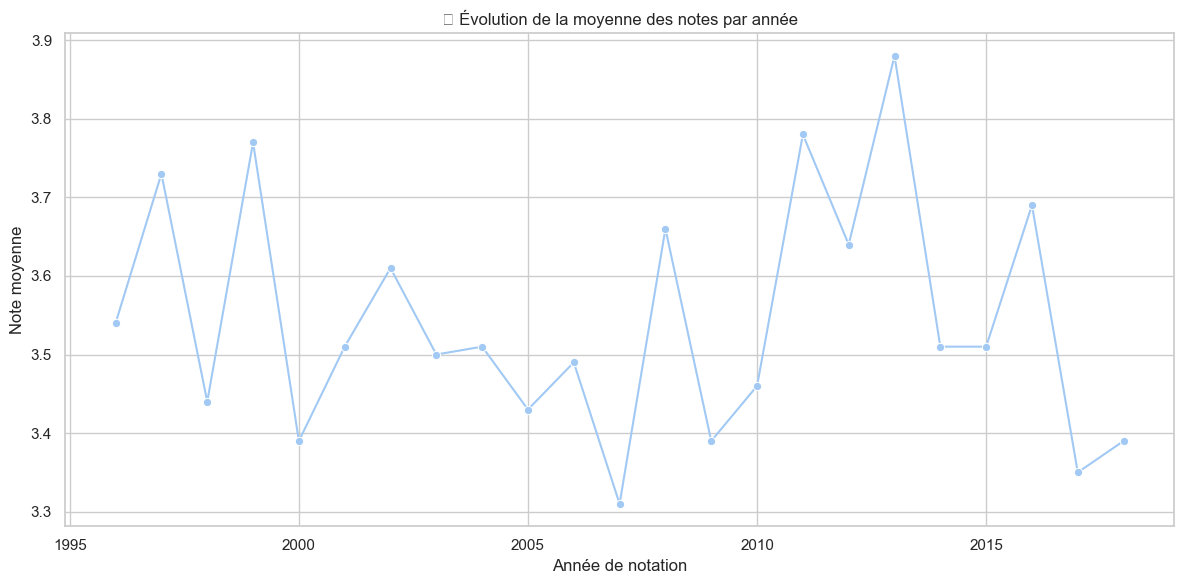

In [28]:


plt.figure(figsize=(12, 6))
sns.lineplot(data=notes_par_annee, x="annee", y="moyenne_notes", marker='o')
plt.title("📈 Évolution de la moyenne des notes par année")
plt.ylabel("Note moyenne")
plt.xlabel("Année de notation")
plt.grid(True)
plt.tight_layout()
plt.show()


## 🧠 Interprétation

- Une stabilité ou une tendance peut se dégager selon les périodes.
- Des années avec des notes plus basses ou plus hautes peuvent indiquer :
  - une évolution dans la perception du public,
  - des changements dans les types de films consommés,
  - ou des biais liés aux utilisateurs actifs à ces moments-là.

> Cela peut également servir à affiner le calcul du score pondéré IMDb par période si nécessaire.


# 4. 📅 Évolution temporelle par genre

Dans cette partie de l'analyse, nous allons étudier l'évolution des notes moyennes des films au fil des années, selon leur genre. Cette analyse permet d'examiner l'impact de l'année de sortie sur les notes données par les utilisateurs et d'identifier les tendances pour chaque genre spécifique.


## 4.1. 🎞️ Évolution des notes par décennie de sortie des films

Nous allons maintenant observer comment les films sont notés **en fonction de leur année de sortie**, indépendamment de la date à laquelle les notes ont été données. Cela permet de répondre à des questions comme :
- Les films des années 80 ou 90 sont-ils mieux perçus aujourd’hui ?
- Existe-t-il des décennies "privilégiées" dans la perception des spectateurs ?
- Observe-t-on une baisse ou une hausse de la qualité perçue au fil des époques ?

> Cette analyse croise la table `ratings` avec `movies`, en regroupant les films par **décennie de sortie**.


In [37]:
query = """
SELECT 
    FLOOR(m."year" / 10) * 10 AS decennie,
    COUNT(*) AS nb_votes,
    ROUND(AVG(r."rating")::numeric, 2) AS moyenne_notes
FROM ratings r
JOIN movies m ON r."movieId" = m."movieId"
WHERE m."year" IS NOT NULL
GROUP BY decennie
ORDER BY decennie;
"""
notes_par_decennie = pd.read_sql_query(query, engine)
notes_par_decennie

,decennie,nb_votes,moyenne_notes
0,1900.0,8,3.31
1,1910.0,8,3.31
2,1920.0,125,3.74
3,1930.0,687,3.73
4,1940.0,1101,3.87
5,1950.0,1784,3.85
6,1960.0,2858,3.81
7,1970.0,4995,3.78
8,1980.0,12912,3.52
9,1990.0,37087,3.43


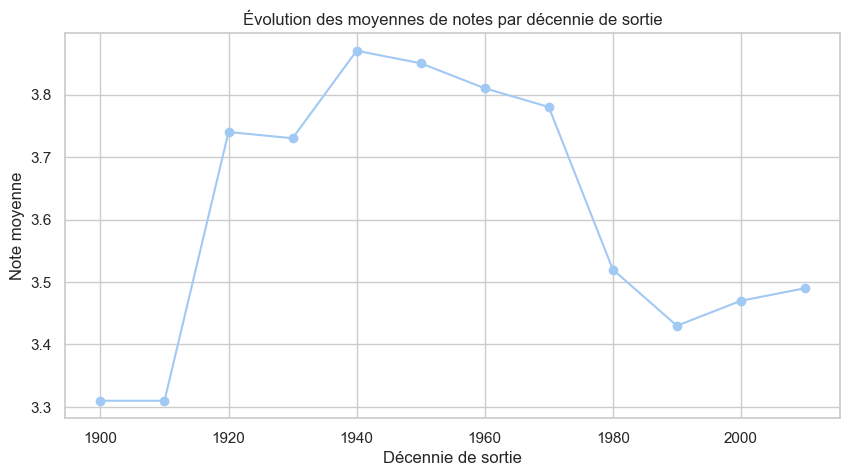

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(notes_par_decennie["decennie"], notes_par_decennie["moyenne_notes"], marker='o')
plt.title("Évolution des moyennes de notes par décennie de sortie")
plt.xlabel("Décennie de sortie")
plt.ylabel("Note moyenne")
plt.grid(True)
plt.show()


## 🧠 Interprétation

- On peut identifier les décennies les mieux notées, ce qui donne des **indices sur les époques "cultes" du cinéma**.
- Si une décennie récente a des notes faibles malgré de nombreux votes, cela peut indiquer :
  - une lassitude du public,
  - une baisse perçue de la qualité,
  - ou un biais générationnel (les anciens films sont mieux notés par nostalgie).
- Cela peut aussi guider une **stratégie éditoriale** pour une plateforme : remise en avant de certains classiques, repositionnement de certains films récents, etc.

> Ces résultats peuvent être croisés ensuite avec les **genres** pour voir si certaines décennies ont produit des films marquants dans des catégories spécifiques.


In [39]:
query = """
WITH genres_exploded AS (
    SELECT 
        "movieId",
        FLOOR("year" / 10) * 10 AS decennie,
        UNNEST(string_to_array("genres", '|')) AS genre
    FROM movies
    WHERE "year" IS NOT NULL
)

SELECT 
    g.decennie,
    g.genre,
    COUNT(*) AS nb_votes,
    ROUND(AVG(r."rating")::numeric, 2) AS moyenne_notes
FROM genres_exploded g
JOIN ratings r ON g."movieId" = r."movieId"
GROUP BY g.decennie, g.genre
ORDER BY g.decennie, g.genre;
"""

notes_par_decennie_genre = pd.read_sql_query(query, engine)
notes_par_decennie_genre.head()


,decennie,genre,nb_votes,moyenne_notes
0,1900.0,Action,5,3.5
1,1900.0,Adventure,5,3.5
2,1900.0,Animation,1,4.0
3,1900.0,Comedy,1,4.0
4,1900.0,Crime,2,2.5


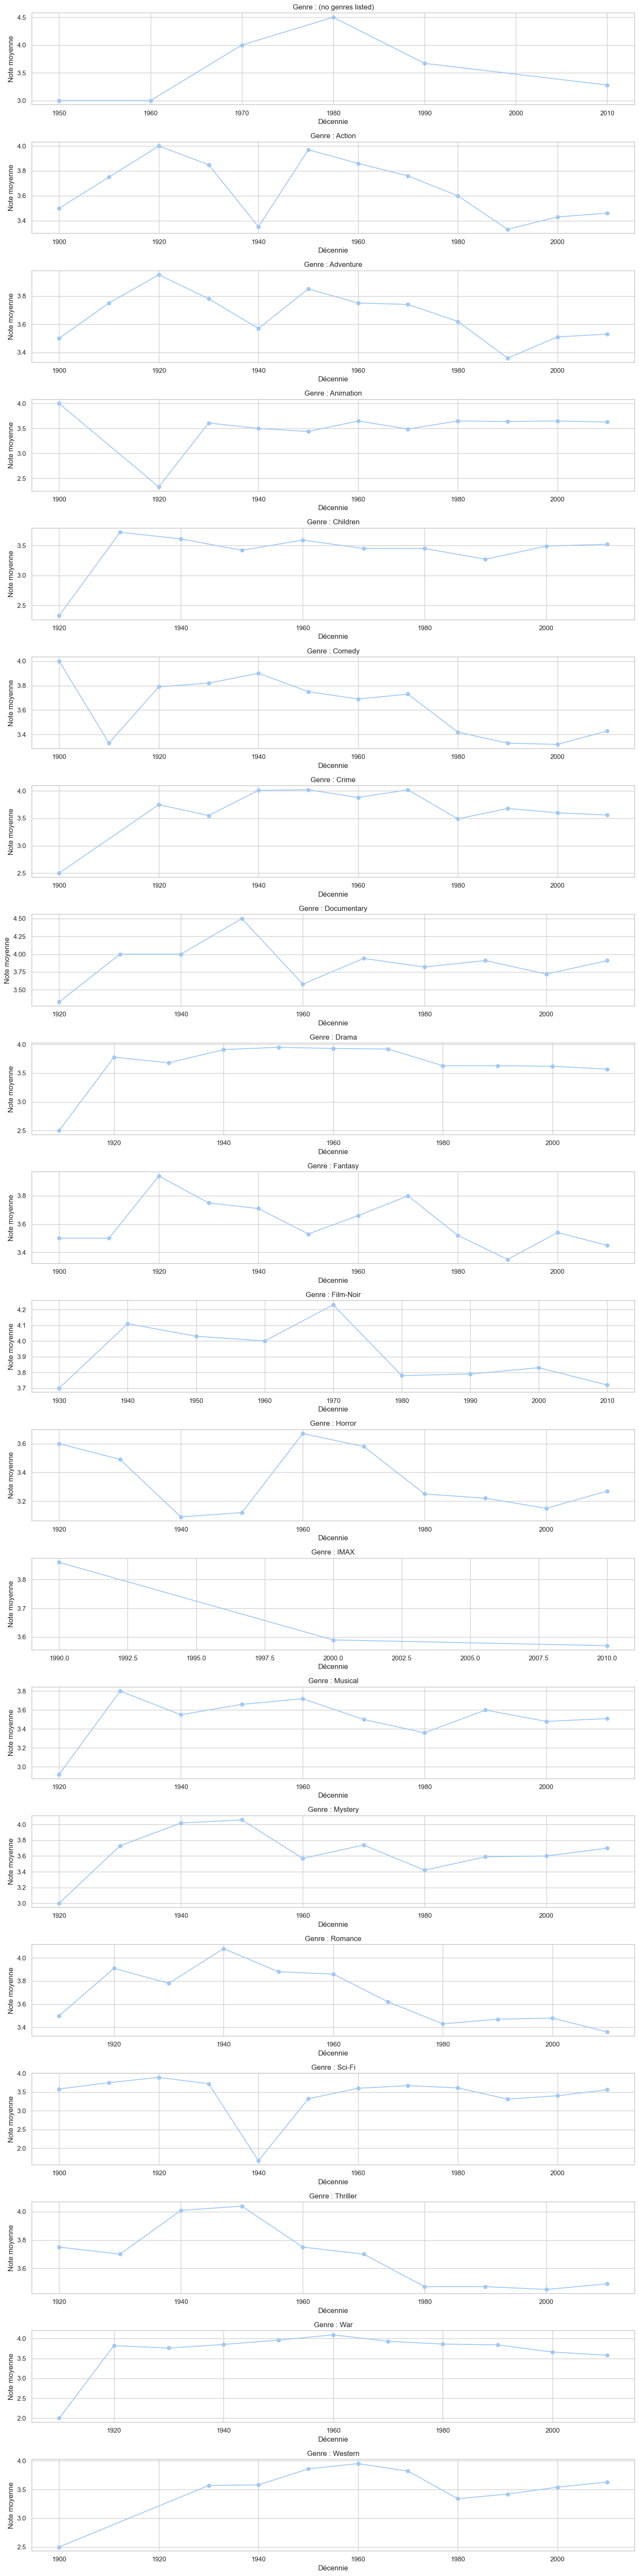

In [41]:
import matplotlib.pyplot as plt

# On récupère tous les genres uniques
genres_uniques = notes_par_decennie_genre["genre"].unique()

# Définir la taille globale des figures
plt.figure(figsize=(15, len(genres_uniques) * 3))

# Tracer un graphique par genre
for i, genre in enumerate(sorted(genres_uniques), start=1):
    plt.subplot(len(genres_uniques), 1, i)
    data = notes_par_decennie_genre[notes_par_decennie_genre["genre"] == genre]
    plt.plot(data["decennie"], data["moyenne_notes"], marker='o')
    plt.title(f"Genre : {genre}")
    plt.xlabel("Décennie")
    plt.ylabel("Note moyenne")
    plt.grid(True)
    plt.tight_layout()

plt.show()


## 🧠 Interprétation des tendances par genre

L'analyse des courbes d'évolution des **notes moyennes par décennie et par genre** révèle plusieurs tendances intéressantes :

- 🎭 **Drama** : genre stable et bien noté à travers les décennies (autour de 3.5–3.7), apprécié de manière constante.
- 😂 **Comedy** : légère baisse depuis les années 2000 ; l’humour semble diviser davantage les spectateurs récents.
- 👽 **Science-Fiction** : forte progression dans les années 80–90, puis remontée récente grâce à des productions ambitieuses.
- 💥 **Action** : notes plus variables ; baisse dans les années 2000 suivie d’un regain avec certaines franchises modernes.
- 🧙 **Fantasy** : pic clair dans les années 2000 (LOTR, Harry Potter), puis stabilisation.
- 🧟 **Horror** : généralement en dessous de la moyenne, avec des pics ponctuels (années 80, années 2010) — genre clivant.
- 🕵️ **Thriller / Mystery** : appréciation stable, proche du drama, avec de bons scores constants.

### 🔎 En résumé :
- Les **genres narratifs** (drame, thriller) sont les plus **constants** dans le temps.
- Les **genres émotionnels ou sensoriels** (comédie, horreur) varient plus selon les époques et les modes culturelles.
- Certains genres ont connu des **"âges d’or"** visibles dans les courbes (ex : fantasy dans les années 2000).

> Cette analyse peut aider une plateforme à repérer les genres les plus valorisés selon les générations et à mieux recommander ses contenus.


## 5.1. 🧩 Segmentation des utilisateurs par comportement de notation

Dans cette partie, nous allons explorer le comportement des utilisateurs pour identifier des **profils types** selon leur manière de noter :

- Utilisateurs généreux ou sévères
- Cinéphiles très actifs
- Profils polarisés ou modérés

Cela nous permettra ensuite d’adapter les recommandations ou d’identifier des tendances de groupe.


In [42]:
# 📥 Chargement des données utilisateur
query = """
WITH user_stats AS (
    SELECT 
        r."userId",
        COUNT(*) AS nb_notes,
        ROUND(AVG(r."rating")::numeric, 2) AS moyenne_notes,
        ROUND(STDDEV(r."rating")::numeric, 2) AS ecart_type_notes
    FROM ratings r
    GROUP BY r."userId"
)
SELECT *
FROM user_stats
ORDER BY nb_notes DESC;
"""

profils_utilisateurs = pd.read_sql_query(query, engine)
profils_utilisateurs.head()


,userId,nb_notes,moyenne_notes,ecart_type_notes
0,414,2698,3.39,0.93
1,599,2478,2.64,0.82
2,474,2108,3.40,0.83
3,448,1864,2.85,1.03
4,274,1346,3.24,0.76


## 5.1. 🧩 Segmentation des utilisateurs par comportement de notation (avec catégories)

Nous allons enrichir notre analyse précédente en attribuant à chaque utilisateur un **profil** basé sur sa moyenne de notes :
- **Généreux** : moyenne ≥ 4.0
- **Modéré** : moyenne entre 3.0 et 4.0
- **Sévère** : moyenne < 3.0

Cela permettra de mieux cibler les recommandations ou de détecter des groupes d’intérêt.


In [43]:
# 📥 Chargement avec catégorisation des profils utilisateurs
query = """
WITH user_stats AS (
    SELECT 
        r."userId",
        COUNT(*) AS nb_notes,
        ROUND(AVG(r."rating")::numeric, 2) AS moyenne_notes,
        ROUND(STDDEV(r."rating")::numeric, 2) AS ecart_type_notes
    FROM ratings r
    GROUP BY r."userId"
)

SELECT *,
    CASE 
        WHEN moyenne_notes >= 4 THEN 'Généreux'
        WHEN moyenne_notes >= 3 THEN 'Modéré'
        ELSE 'Sévère'
    END AS profil
FROM user_stats
ORDER BY nb_notes DESC;
"""

profils_categorises = pd.read_sql_query(query, engine)
profils_categorises.head()


,userId,nb_notes,moyenne_notes,ecart_type_notes,profil
0,414,2698,3.39,0.93,Modéré
1,599,2478,2.64,0.82,Sévère
2,474,2108,3.40,0.83,Modéré
3,448,1864,2.85,1.03,Sévère
4,274,1346,3.24,0.76,Modéré


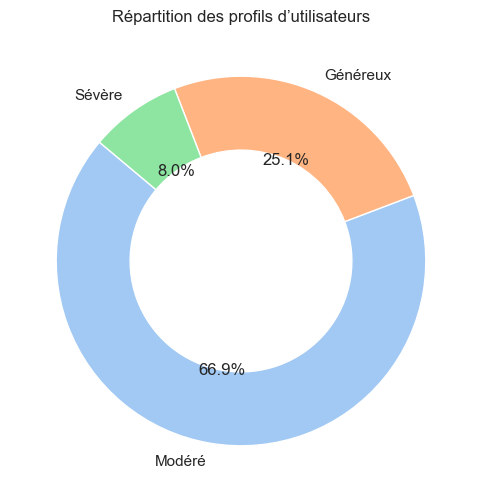

In [44]:
# 📊 Camembert des profils utilisateurs

import matplotlib.pyplot as plt

# Comptage des profils
profil_counts = profils_categorises["profil"].value_counts()

# Tracé
plt.figure(figsize=(6, 6))
plt.pie(
    profil_counts,
    labels=profil_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)  # donut effect
)
plt.title("Répartition des profils d’utilisateurs")
plt.show()


## 5.3. ⚡️ Identification des films polarisants (écart-type élevé)

Nous allons chercher les films les plus **clivants**, c’est-à-dire ceux qui reçoivent à la fois de très bonnes **et** de très mauvaises notes.

Ces films présentent :
- Un **écart-type élevé** dans les notes (divergence forte d’opinions),
- Un nombre de votes **suffisant** pour être significatif (ex : au moins 50 votes),
- Des cas intéressants pour les plateformes de streaming (films cultes, controversés, etc.).

> Cette analyse met en lumière des films à double lecture : aimés par certains, détestés par d'autres.


In [46]:
query = """
WITH film_stats AS (
    SELECT 
        r."movieId",
        COUNT(*) AS nb_votes,
        ROUND(AVG(r."rating")::numeric, 2) AS moyenne_notes,
        ROUND(STDDEV(r."rating")::numeric, 2) AS ecart_type
    FROM ratings r
    GROUP BY r."movieId"
    HAVING COUNT(*) >= 50
)

SELECT 
    fs.*,
    m."title",
    m."year"
FROM film_stats fs
JOIN movies m ON fs."movieId" = m."movieId"
ORDER BY fs.ecart_type DESC
LIMIT 20;
"""

films_polarisants = pd.read_sql_query(query, engine)
films_polarisants


,movieId,nb_votes,moyenne_notes,ecart_type,title,year
0,2710,64,2.80,1.37,"Blair Witch Project, The (1999)",1999
1,168,54,3.08,1.30,First Knight (1995),1995
2,2683,121,3.20,1.22,Austin Powers: The Spy Who Shagged Me (1999),1999
3,1407,70,3.20,1.20,Scream (1996),1996
4,4308,55,3.59,1.20,Moulin Rouge (2001),2001
5,784,54,2.81,1.18,"Cable Guy, The (1996)",1996
6,1391,86,3.09,1.18,Mars Attacks! (1996),1996
7,788,82,2.73,1.17,"Nutty Professor, The (1996)",1996
8,3785,50,2.92,1.17,Scary Movie (2000),2000
9,2395,56,3.54,1.16,Rushmore (1998),1998


## 🧠 Interprétation

- Ces films génèrent des réactions **très partagées** : certains les adorent, d’autres les rejettent.
- Cela peut indiquer :
  - des œuvres artistiquement audacieuses ou expérimentales,
  - des comédies particulières, des thrillers ambigus, des films provocateurs,
  - ou des films qui vieillissent mal / sont redécouverts.
- Pour une plateforme de streaming, cela peut alimenter une **catégorie “films qui divisent”** ou “à (re)découvrir malgré les controverses”.

> Exemple d’exploitation : proposer ces films à des utilisateurs curieux ou qui aiment les expériences cinématographiques fortes.
